In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("BlackMetal.csv")

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.362251e+09,154,self.BlackMetal,19j8zf,Dead's real suicide note.,TheInundation,163,9,13,http://www.reddit.com/r/BlackMetal/comments/19...,I always thought that Mayhem's Dead's suicide ...,NaN,False,self,t5_2rta0,1362416632.0,NaN,NaN,True,t3_19j8zf,http://www.reddit.com/r/BlackMetal/comments/19...,NaN
1,1.373923e+09,130,brutalashell.com,1id80t,Helvete to reopen as Black Metal Museum.,MarquisDesMoines,139,9,5,http://www.reddit.com/r/BlackMetal/comments/1i...,NaN,NaN,False,http://f.thumbs.redditmedia.com/qICn28ln4kNCh4...,t5_2rta0,False,NaN,NaN,False,t3_1id80t,http://www.brutalashell.com/2013/07/go-to-hell...,NaN
2,1.344432e+09,105,i.imgur.com,xvoc3,Darkthrone with Mayhem at Helvete in 1991,AmusingAccountName,113,8,19,http://www.reddit.com/r/BlackMetal/comments/xv...,NaN,NaN,False,http://a.thumbs.redditmedia.com/e2JvZKUE318Yle...,t5_2rta0,False,NaN,NaN,False,t3_xvoc3,http://i.imgur.com/DKn4l.jpg,NaN
3,1.373970e+09,101,francetvinfo.fr,1iel8z,"Varg Vikernes arrested in France (french link,...",thelightcarrier,108,7,44,http://www.reddit.com/r/BlackMetal/comments/1i...,NaN,NaN,False,http://a.thumbs.redditmedia.com/mU1u96-xG1MEtu...,t5_2rta0,False,NaN,NaN,False,t3_1iel8z,http://www.francetvinfo.fr/france/un-neonazi-n...,NaN
4,1.342076e+09,102,theatlantic.com,wfj21,When Black Metal's Anti-Religious Message Gets...,DiscoRage,113,11,22,http://www.reddit.com/r/BlackMetal/comments/wf...,NaN,NaN,False,http://d.thumbs.redditmedia.com/J4iTSXbdoYYVHz...,t5_2rta0,False,NaN,NaN,False,t3_wfj21,http://www.theatlantic.com/entertainment/archi...,NaN


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  935 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                77 non-null     str    
 11  link_flair_text         102 non-null    str    
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

,created_utc,score,ups,downs,num_comments,link_flair_css_class,author_flair_css_class
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,0.0,0.0
mean,1.353991e+09,21.501000,25.768000,4.267000,7.268000,NaN,NaN
std,1.607903e+07,13.784848,16.003196,4.203258,13.156872,NaN,NaN
min,1.305144e+09,9.000000,11.000000,0.000000,0.000000,NaN,NaN
25%,1.343145e+09,13.000000,16.000000,2.000000,1.000000,NaN,NaN
50%,1.356541e+09,17.000000,21.000000,3.000000,3.000000,NaN,NaN
75%,1.367524e+09,24.000000,29.000000,6.000000,7.000000,NaN,NaN
max,1.376945e+09,154.000000,163.000000,38.000000,107.000000,NaN,NaN


In [4]:
df.isnull().sum()

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      65
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   923
link_flair_text            898
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class    1000
is_self                      0
name                         0
url                          0
distinguished              999
dtype: int64

In [5]:
X = df.select_dtypes(include=['int64','float64'])

In [7]:
print(X.isna().sum())

created_utc                  0
score                        0
ups                          0
downs                        0
num_comments                 0
link_flair_css_class      1000
author_flair_css_class    1000
dtype: int64


In [9]:
X.info()
X.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   ups                     1000 non-null   int64  
 3   downs                   1000 non-null   int64  
 4   num_comments            1000 non-null   int64  
 5   link_flair_css_class    0 non-null      float64
 6   author_flair_css_class  0 non-null      float64
dtypes: float64(3), int64(4)
memory usage: 54.8 KB


,created_utc,score,ups,downs,num_comments,link_flair_css_class,author_flair_css_class
0,1.362251e+09,154,163,9,13,NaN,NaN
1,1.373923e+09,130,139,9,5,NaN,NaN
2,1.344432e+09,105,113,8,19,NaN,NaN
3,1.373970e+09,101,108,7,44,NaN,NaN
4,1.342076e+09,102,113,11,22,NaN,NaN


In [13]:
X = X.select_dtypes(include=['number'])

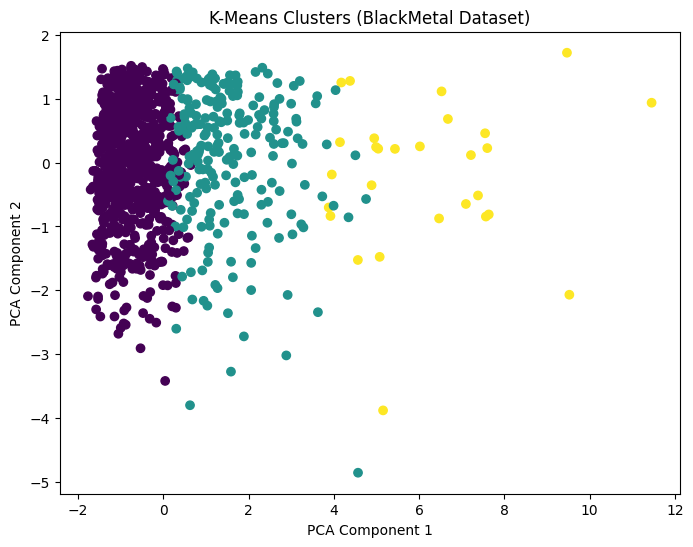

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Run K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)

plt.title("K-Means Clusters (BlackMetal Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [16]:
df.to_csv("BlackMetal_clustered.csv", index=False)